Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

### Resolución de la tarea 1 (tablero de ajedrez)

En este caso he optado por crear variables que representen en que coordenada empieza cada cuadrado, tanto en filas como en columnas (los cuadrados serán de 100x100) y otra variable para almacenar si la fila que pintamos es par o impar

Se recorren filas y columnas a través 2 bucles, en los que se utiliza la variable numero_fila para determinar donde se empieza a pintar la fila, de forma que se puede empezar en la posición 0 en las filas impares y en la posición 100 en las pares, para lograr el efecto de un tablero de ajedrez

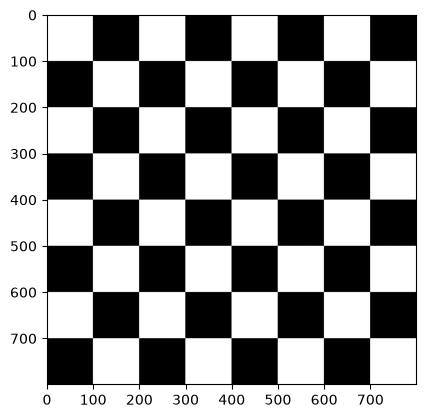

In [3]:
tablero_ajedrez = np.zeros((800, 800, 1), dtype = np.uint8)

# recorreremos el tablero por filas y columnas, haciendo cuadrados de 100x100
inicio_fila = 0
final_fila = 100

inicio_columna = 0
final_columna = 100

numero_fila = 1

while inicio_fila <= 800:

    while inicio_columna <= 800:
        tablero_ajedrez[inicio_fila:final_fila,inicio_columna:final_columna,0] = 128 
        inicio_columna += 200
        final_columna += 200

    inicio_fila += 100
    final_fila += 100
    numero_fila += 1

    if numero_fila % 2 == 0:
        inicio_columna = 100
        final_columna = 200
    else:
        inicio_columna = 0
        final_columna = 100

plt.imshow(tablero_ajedrez, cmap='gray')
plt.show()

Una vez terminado, le he pedido a GPT-5.6 Luna que resuelva la tarea con la única instrucción de que la resuelva de la manera más eficiente posible, y ha dado la siguiente respuesta:

"La forma más eficiente es generarlo de manera vectorizada con NumPy, sin recorrer píxel a píxel ni usar bucles. La paridad de la fila y la columna determina si cada casilla es negra o blanca"

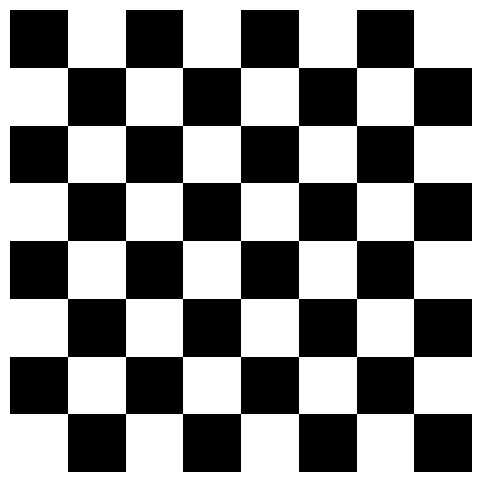

In [4]:
# Dimensiones del tablero
alto = 800
ancho = 800
lado_casilla = 100

# Número de casilla correspondiente a cada fila y columna
filas = np.arange(alto) // lado_casilla
columnas = np.arange(ancho) // lado_casilla

# Alternancia de colores mediante la paridad fila + columna
tablero_ajedrez = (
    (filas[:, np.newaxis] + columnas[np.newaxis, :]) % 2 * 255
).astype(np.uint8)

# Visualización
plt.figure(figsize=(6, 6))
plt.imshow(
    tablero_ajedrez,
    cmap='gray',
    vmin=0,
    vmax=255,
    interpolation='nearest'
)
plt.axis('off')
plt.show()

A diferencia de mí, GTP-5.6 Luna planteó la solución al problema utilizando directamente utilidades de NumPy, almacenó las variables de alto y ancho y de lado de cada cuadrado

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

### Resolución de la tarea 2 (imagen estilo Mondrian)

Para esta tarea y observando la imagen del enlace de la tarea, primero vamos a crear un lienzo blanco, sobre él dibujaremos líneas negras y por último usaremos rectángulos y cuadrados para colorear el interior de las formas que dejen las líneas negras

Nota: se tiene en cuenta que el grosor por linea es de 10

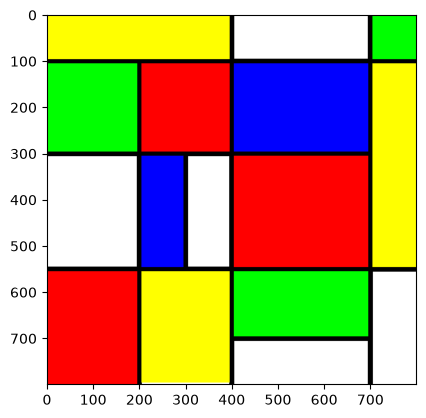

In [5]:
mondrian = np.zeros((alto,ancho,3), dtype = np.uint8)
mondrian[:,:,0] = 255
mondrian[:,:,1] = 255
mondrian[:,:,2] = 255

cv2.line(mondrian,(400, 0),(400,800),(0,0,0),10)
cv2.line(mondrian,(700, 0),(700,800),(0,0,0),10)

cv2.line(mondrian,(0, 100),(800,100),(0,0,0),10)
cv2.line(mondrian,(0, 550),(800,550),(0,0,0),10)

cv2.line(mondrian,(0, 300),(700,300),(0,0,0),10)
cv2.line(mondrian,(200, 100),(200,800),(0,0,0),10)
cv2.line(mondrian,(400, 700),(700,700),(0,0,0),10)
cv2.line(mondrian,(300, 300),(300,550),(0,0,0),10)

cv2.rectangle(mondrian,(0,105),(195,295),(0,255,0),-1)
cv2.rectangle(mondrian,(205,105),(395,295),(255,0,0),-1)
cv2.rectangle(mondrian,(205,305),(295,545),(0,0,255),-1)
cv2.rectangle(mondrian,(405,105),(695,295),(0,0,255),-1)
cv2.rectangle(mondrian,(405,305),(695,545),(255,0,0),-1)
cv2.rectangle(mondrian,(405,555),(695,695),(0,255,0),-1)
cv2.rectangle(mondrian,(205,555),(395,795),(255,255,0),-1)
cv2.rectangle(mondrian,(0,0),(395,95),(255,255,0),-1)
cv2.rectangle(mondrian,(705,105),(800,545),(255,255,0),-1)
cv2.rectangle(mondrian,(705,0),(800,95),(0,255,0),-1)
cv2.rectangle(mondrian,(0,555),(195,800),(255,0,0),-1)

plt.imshow(mondrian) 
plt.show()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


### Resolución tarea 3 (pintar círculos en el píxel más claro y más oscuro)

Para ello vamos a partir del código básico en el que mostramos la cámara y vamos a buscar el píxel de mayor intensidad con el de menor intensidad usando la función de cv2 minMaxLoc, la cual devuelve la intensidad del pixel más claro y más oscuro, y una tupla para cada pixel con su posición (x,y)

Previamente debemos pasar el frame a escala de grises para determinar el pixel mas claro y el más oscuro en base a su brillo

In [6]:
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
  
    # Hay nuevo fotograma
    if ret:  
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        min_val, max_val, min_coord, max_coord = cv2.minMaxLoc(gray)

        # pixel más oscuro de color rojo
        cv2.circle(frame, (min_coord[0], min_coord[1]), 10, (0, 0, 255));

        # pixel más claro de color amarillo
        cv2.circle(frame, (max_coord[0], max_coord[1]), 10, (0, 255, 255));

        # Muestra fotograma
        cv2.imshow('Vid', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

Si ejecutamos el codigo anterior, vemos que si hay varios elementos de una intensidad similar, el círculo que le corresponde a dicha intensidad "salta" de un lado para otro dentro de los píxeles que tienen dicha intensidad, por lo que parece que funciona a saltos

**TAREA**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

### Resolución tarea 4 (pop art personalizado)

Para esta tarea se ha decidido imitar la composición del siguiente pop art: https://es.wikipedia.org/wiki/Arte_pop#/media/Archivo:David_Bowie-Gil_Zetbase.jpg

De forma que es necesario primero crear un collage de 3x3 y posteriormente ir añadiendo los planos correspondientes por fila y columna, para luego jugar con la composición de colores de cada cuadrado dentro del collage

In [36]:
vid = cv2.VideoCapture(0)

#Dimensiones de la cámara
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

#Fuerzo a mitad de resolución para ocupar menos pantalla
w=int(w/2)
h=int(h/2)

vid.set(cv2.CAP_PROP_FRAME_WIDTH, w)
vid.set(cv2.CAP_PROP_FRAME_HEIGHT, h)

#Imagen conjunta 3x3 original
collage = np.zeros((h*3,w*3,3), dtype = np.uint8)

aa = collage[0:h,     0:w]
ab = collage[0:h,     w:w*2]
ac = collage[0:h,     w*2:3*w]

ba = collage[h:h*2,   0:w]
bb = collage[h:h*2,   w:w*2]
bc = collage[h:h*2,   w*2:w*3]

ca = collage[h*2:h*3, 0:w]
cb = collage[h*2:h*3, w:w*2]
cc = collage[h*2:h*3, w*2:w*3]


while True:      
    # fotograma a fotograma
    ret, frameIN = vid.read()

    #Menor tamaño
    frame = cv2.resize(frameIN, (int(w),int(h)),cv2.INTER_NEAREST)

    if ret:
        #Separamos canales
        r = frame[:,:,2]
        g = frame[:,:,1]
        b = frame[:,:,0]

        #Jugamos con los valores de los planos
        aa[:,:,0] = 255 - b
        aa[:,:,1] = g
        aa[:,:,2] = r

        ab[:,:,0] = b
        ab[:,:,1] = 255 - g
        ab[:,:,2] = r

        ac[:,:,0] = b
        ac[:,:,1] = g
        ac[:,:,2] = 255 - r

        ba[:,:,0] = b // 2
        ba[:,:,1] = 255 - g
        ba[:,:,2] = r

        bb[:,:,0] = b
        bb[:,:,1] = g // 2
        bb[:,:,2] = 255 - r

        bc[:,:,0] = 255 - b
        bc[:,:,1] = g
        bc[:,:,2] = r // 2

        ca[:,:,0] = 128 - b // 2
        ca[:,:,1] = 255 - g
        ca[:,:,2] = r

        cb[:,:,0] = b
        cb[:,:,1] = 128 - g // 2
        cb[:,:,2] = 255 - r

        cc[:,:,0] = 255 - b
        cc[:,:,1] = g
        cc[:,:,2] = 128 - r // 2


        # Muestra composición
        cv2.imshow('Cam', collage)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()